# KL Incoherence

From *The Hot Mess of AI* (McKee et al., ICLR 2026).

The core idea: decompose a model's cross-entropy error into **bias** and **variance** — but using KL divergence instead of squared error, because outputs are probability distributions.

$$\underbrace{\mathbb{E}_\varepsilon[\text{CE}(y, f_\varepsilon)]}_{\text{total error}} = \underbrace{D_{\text{KL}}(y \| \bar{f})}_{\text{bias}^2} + \underbrace{\mathbb{E}_\varepsilon[D_{\text{KL}}(\bar{f} \| f_\varepsilon)]}_{\text{KL incoherence (variance)}}$$

**KL incoherence** is the variance term: how much do individual runs scatter around the model's own consensus?

The **incoherence ratio** = variance / total error. The paper's claim: this ratio *increases* with model scale.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from scipy.stats import dirichlet

np.random.seed(42)

def kl_divergence(p, q, eps=1e-12):
    """D_KL(p || q) = sum_c p[c] * log(p[c] / q[c]).
    
    Measures extra bits needed if you encode p using q's codebook.
    Asymmetric: KL(p||q) != KL(q||p).
    """
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q), axis=-1)

def cross_entropy(y, f, eps=1e-12):
    """CE(y, f) = -sum_c y[c] * log(f[c]).
    
    Since y is one-hot, this equals -log(f[correct_class]).
    Also equals D_KL(y||f) + H(y), where H(y)=0 for one-hot y.
    """
    f = np.clip(f, eps, 1)
    return -np.sum(y * np.log(f), axis=-1)

## Simulating a Classification Model

We simulate a 3-class problem. Each "model run" with randomness ε (different seed, temperature, dropout) produces a distribution over classes.

To mimic scaling behavior:
- **Small model**: high bias (consensus drifts from truth), low variance (runs are consistent with each other)
- **Large model**: low bias (consensus is close to truth), high variance (individual runs scatter)

We model each run's logits as: `logit = true_signal + bias_offset + noise * variance_scale`

In [4]:
def simulate_model_runs(n_runs, n_classes, true_class, bias_strength, variance_strength):
    """
    Simulate n_runs of a model on one example.
    
    - bias_strength: how much the average prediction is pulled away from truth
      (systematic error — same direction every run)
    - variance_strength: how much each run deviates from the average
      (random error — different direction each run)
    
    Returns: (runs, y, f_bar)
      runs: shape (n_runs, n_classes) — each row is one model run's output
      y: one-hot true label
      f_bar: mean prediction (consensus)
    """
    y = np.zeros(n_classes)
    y[true_class] = 1.0
    
    # True signal: strong logit on correct class
    true_logits = np.zeros(n_classes)
    true_logits[true_class] = 3.0
    
    # Bias: a fixed offset pushing toward a wrong class (class 1)
    bias_offset = np.zeros(n_classes)
    wrong_class = (true_class + 1) % n_classes
    bias_offset[wrong_class] = bias_strength
    bias_offset[true_class] = -bias_strength * 0.5
    
    runs = []
    for _ in range(n_runs):
        # Each run: true signal + systematic bias + random noise
        noise = np.random.randn(n_classes) * variance_strength
        logits = true_logits + bias_offset + noise
        runs.append(softmax(logits))
    
    runs = np.array(runs)         # (n_runs, n_classes)
    f_bar = runs.mean(axis=0)     # consensus: average across runs
    f_bar /= f_bar.sum()          # renormalize (mean of softmaxes isn't a proper softmax)
    
    return runs, y, f_bar


def decompose(runs, y, f_bar):
    """
    Compute the bias-variance decomposition.
    
    total_error = E[CE(y, f_eps)]   (average cross-entropy across runs)
    bias        = D_KL(y || f_bar)  (how far consensus is from truth)
    variance    = E[D_KL(f_bar || f_eps)]  (how much runs scatter from consensus)
    
    Note: bias + variance should approximately equal total_error.
    The small residual is because mean-of-softmaxes != softmax-of-means.
    """
    total_error = cross_entropy(y, runs).mean()          # E_eps[CE(y, f_eps)]
    bias        = kl_divergence(y, f_bar)                # D_KL(y || f_bar)
    variance    = kl_divergence(f_bar, runs).mean()      # E_eps[D_KL(f_bar || f_eps)]
    incoherence_ratio = variance / total_error if total_error > 0 else 0
    
    return {
        "total_error": total_error,
        "bias": bias,
        "variance": variance,
        "incoherence_ratio": incoherence_ratio,
    }

## Single Example: Small vs. Large Model

In [5]:
N_RUNS = 500
N_CLASSES = 3
TRUE_CLASS = 0

small_runs, y, small_fbar = simulate_model_runs(
    N_RUNS, N_CLASSES, TRUE_CLASS,
    bias_strength=2.5,    # big systematic offset
    variance_strength=0.3  # small random scatter
)

large_runs, y, large_fbar = simulate_model_runs(
    N_RUNS, N_CLASSES, TRUE_CLASS,
    bias_strength=0.5,    # small systematic offset (better calibrated)
    variance_strength=1.8  # large random scatter (incoherent)
)

small = decompose(small_runs, y, small_fbar)
large = decompose(large_runs, y, large_fbar)

print(f"{'':20} {'Small model':>15} {'Large model':>15}")
print("-" * 52)
for k in ["total_error", "bias", "variance", "incoherence_ratio"]:
    print(f"{k:20} {small[k]:>15.4f} {large[k]:>15.4f}")

                         Small model     Large model
----------------------------------------------------
total_error                   1.1845          0.6693
bias                          1.1477          0.4014
variance                      0.0216          0.6061
incoherence_ratio             0.0183          0.9055


## Visualizing the Decomposition

Stacked bars showing how error breaks down. The key: even if the large model has *lower total error*, its incoherence ratio is higher — a larger fraction of remaining error is random, not systematic.

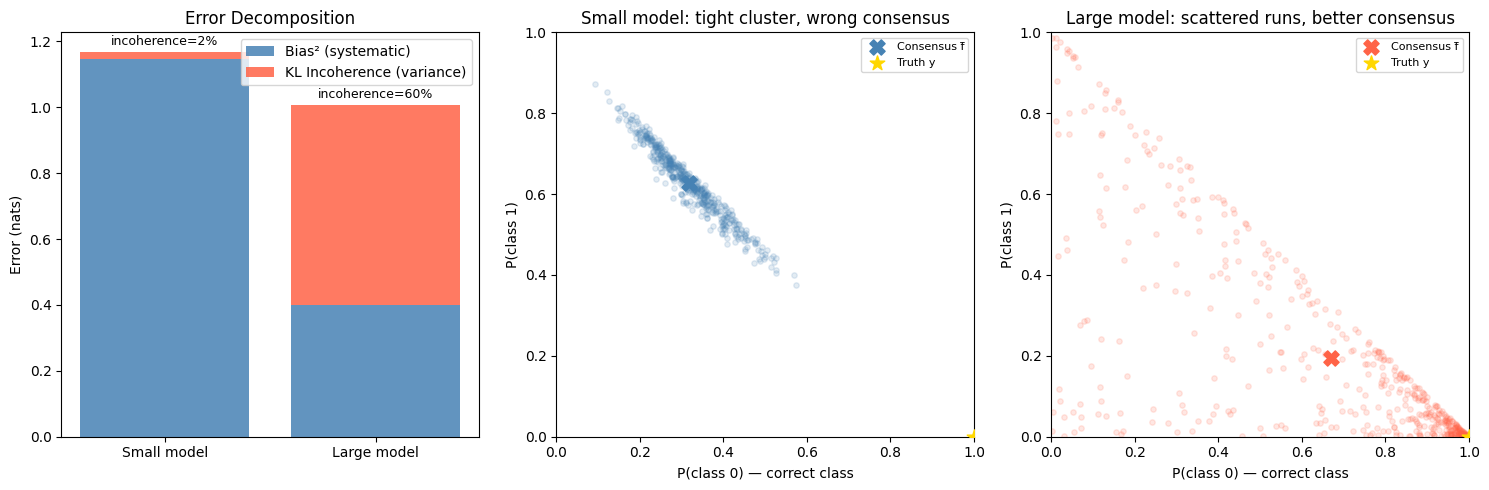

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Stacked bar decomposition ---
ax = axes[0]
models = ["Small model", "Large model"]
biases = [small["bias"], large["bias"]]
variances = [small["variance"], large["variance"]]

x = np.arange(len(models))
ax.bar(x, biases, label="Bias² (systematic)", color="steelblue", alpha=0.85)
ax.bar(x, variances, bottom=biases, label="KL Incoherence (variance)", color="tomato", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Error (nats)")
ax.set_title("Error Decomposition")
ax.legend()
for i, (b, v) in enumerate(zip(biases, variances)):
    ratio = v / (b + v)
    ax.text(i, b + v + 0.02, f"incoherence={ratio:.0%}", ha="center", fontsize=9)

# --- Plot 2: Run scatter for small model ---
ax = axes[1]
ax.scatter(small_runs[:, 0], small_runs[:, 1], alpha=0.15, s=15, color="steelblue")
ax.scatter(*small_fbar[:2], color="steelblue", s=120, marker="X", label="Consensus f̄", zorder=5)
ax.scatter(y[0], y[1], color="gold", s=120, marker="*", label="Truth y", zorder=5)
ax.set_xlabel("P(class 0) — correct class")
ax.set_ylabel("P(class 1)")
ax.set_title("Small model: tight cluster, wrong consensus")
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# --- Plot 3: Run scatter for large model ---
ax = axes[2]
ax.scatter(large_runs[:, 0], large_runs[:, 1], alpha=0.15, s=15, color="tomato")
ax.scatter(*large_fbar[:2], color="tomato", s=120, marker="X", label="Consensus f̄", zorder=5)
ax.scatter(y[0], y[1], color="gold", s=120, marker="*", label="Truth y", zorder=5)
ax.set_xlabel("P(class 0) — correct class")
ax.set_ylabel("P(class 1)")
ax.set_title("Large model: scattered runs, better consensus")
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("kl-incoherence-decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## Scaling Curve: Incoherence Ratio vs. Model Scale

The paper's central empirical claim. As we simulate increasingly "large" models (lower bias, higher variance), the incoherence ratio trends upward even as total error falls.

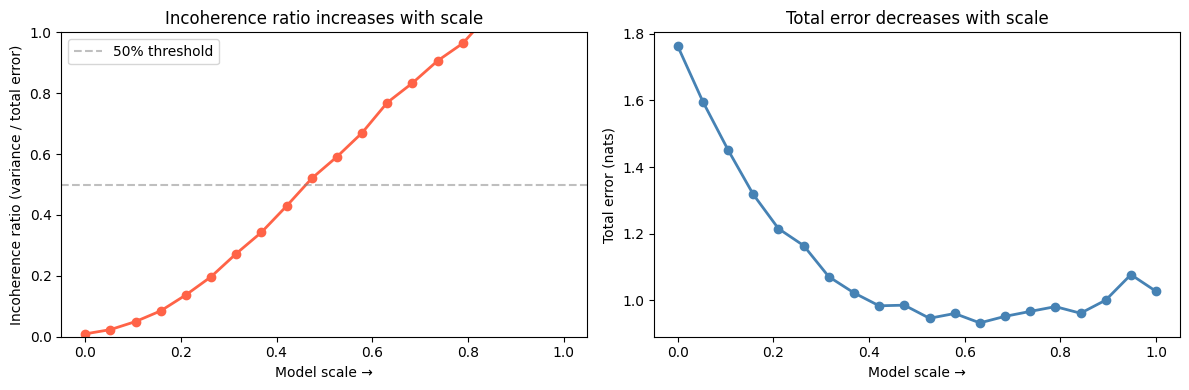

Key: error falls AND incoherence rises — the remaining failures are increasingly random.


In [7]:
# Parameterize "model scale" as an index from 0..1
# At scale=0 (small): high bias, low variance
# At scale=1 (large): low bias, high variance
scale_points = np.linspace(0, 1, 20)

results = []
for s in scale_points:
    bias_str = 3.0 * (1 - s)      # bias decreases with scale
    var_str  = 0.3 + 2.5 * s      # variance increases with scale
    
    # Average over 10 random examples to reduce noise
    ratios, totals = [], []
    for true_c in range(N_CLASSES):
        for _ in range(3):
            runs, y_i, fbar = simulate_model_runs(N_RUNS, N_CLASSES, true_c, bias_str, var_str)
            d = decompose(runs, y_i, fbar)
            ratios.append(d["incoherence_ratio"])
            totals.append(d["total_error"])
    
    results.append({
        "scale": s,
        "incoherence_ratio": np.mean(ratios),
        "total_error": np.mean(totals),
    })

scales = [r["scale"] for r in results]
ratios = [r["incoherence_ratio"] for r in results]
errors = [r["total_error"] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(scales, ratios, "o-", color="tomato", linewidth=2)
ax1.set_xlabel("Model scale →")
ax1.set_ylabel("Incoherence ratio (variance / total error)")
ax1.set_title("Incoherence ratio increases with scale")
ax1.set_ylim(0, 1)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="50% threshold")
ax1.legend()

ax2.plot(scales, errors, "o-", color="steelblue", linewidth=2)
ax2.set_xlabel("Model scale →")
ax2.set_ylabel("Total error (nats)")
ax2.set_title("Total error decreases with scale")

plt.tight_layout()
plt.savefig("kl-incoherence-scaling.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key: error falls AND incoherence rises — the remaining failures are increasingly random.")

## Why This Matters for Alignment

The incoherence ratio tells you what kind of failure you're dealing with:

| Ratio | What it means | How to fix it |
|-------|--------------|---------------|
| Low (biased) | Model consistently fails in the *same* direction | More data / better training signal on that class of inputs |
| High (incoherent) | Model fails *randomly* — unpredictably across runs | Harder: ensembling helps, but fundamental incoherence can't be trained away easily |

For safety evaluation: a model with high incoherence can *pass* safety evals most of the time while occasionally failing badly — and those failures aren't predictable from its average behavior. This is Sohl-Dickstein's "hot mess" intuition: the model isn't reliably safe *or* reliably unsafe; it's chaotically variable.

In [8]:
# Concrete demonstration: two models with same accuracy, different incoherence
# Both get the right answer 70% of the time — but one is biased, one is incoherent

def accuracy_from_runs(runs, true_class):
    return (runs.argmax(axis=1) == true_class).mean()

# Tune to get ~70% accuracy for both
biased_runs, y_b, biased_fbar = simulate_model_runs(1000, 3, 0, bias_strength=1.2, variance_strength=0.3)
incoherent_runs, y_i, incoherent_fbar = simulate_model_runs(1000, 3, 0, bias_strength=0.3, variance_strength=2.0)

print(f"Biased model     — accuracy: {accuracy_from_runs(biased_runs, 0):.1%}")
print(f"Incoherent model — accuracy: {accuracy_from_runs(incoherent_runs, 0):.1%}")
print()

biased_d = decompose(biased_runs, y_b, biased_fbar)
incoherent_d = decompose(incoherent_runs, y_i, incoherent_fbar)

print(f"{'':25} {'Biased':>12} {'Incoherent':>12}")
print("-" * 51)
for k in ["total_error", "bias", "variance", "incoherence_ratio"]:
    print(f"{k:25} {biased_d[k]:>12.4f} {incoherent_d[k]:>12.4f}")

print()
print("Same accuracy, different failure structure.")
print("The incoherent model's failures can't be predicted from its consensus behavior.")

Biased model     — accuracy: 99.7%
Incoherent model — accuracy: 70.0%

                                Biased   Incoherent
---------------------------------------------------
total_error                     0.3509       0.7681
bias                            0.3443       0.4394
variance                        0.0205       0.7654
incoherence_ratio               0.0583       0.9965

Same accuracy, different failure structure.
The incoherent model's failures can't be predicted from its consensus behavior.
